# Data understanding and preparing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels as sm
import statsmodels.api as smt

import warnings
warnings.filterwarnings('ignore')

In [2]:
cpi = pd.read_csv('CPI_train.csv')
cpi['Quarter']=pd.to_datetime(cpi["Quarter"])
cpi.set_index('Quarter', inplace=True)
cpi.shape

(132, 1)

In [3]:
print(cpi.head(7))

             CPI
Quarter         
1990-03-01  50.3
1990-06-01  51.7
1990-09-01  51.3
1990-12-01  51.8
1991-03-01  52.9
1991-06-01  52.7
1991-09-01  53.1


In [4]:
cpi.isnull().sum()

,0
CPI,0


In [5]:
 cpi.describe()

,CPI
count,132.000000
mean,83.634091
std,21.548397
min,50.300000
25%,62.075000
50%,85.650000
75%,103.800000
max,125.600000


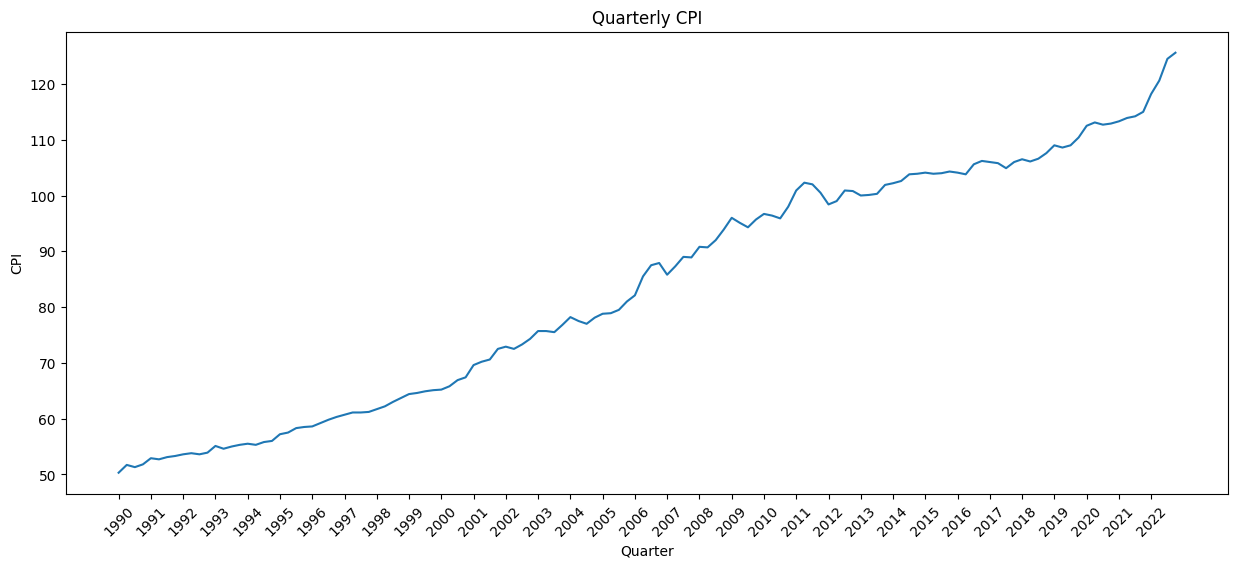

In [6]:
unique_years = pd.Series(cpi.index.year).drop_duplicates().index
unique_year_labels = cpi.index[unique_years].year

plt.figure(figsize=(15, 6))
plt.plot(cpi.index, cpi)
plt.xlabel('Quarter')
plt.ylabel('CPI')
plt.title("Quarterly CPI")
plt.xticks(ticks=cpi.index[unique_years], labels=unique_year_labels, rotation=45)
plt.show()

obviously upward trend, no obvious cycle, no obviously seasonal

variation around the trend does not change over time

## stationary

### ACF PACF plot



[]

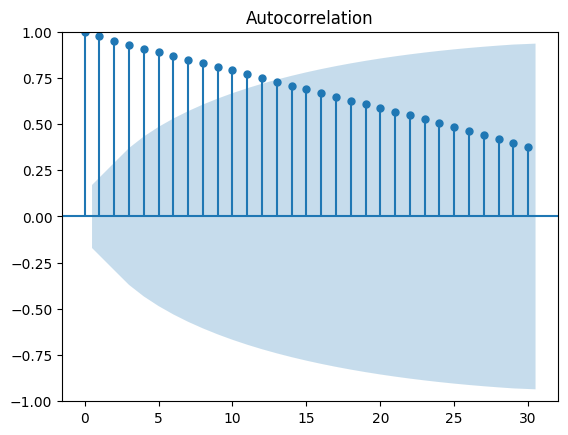

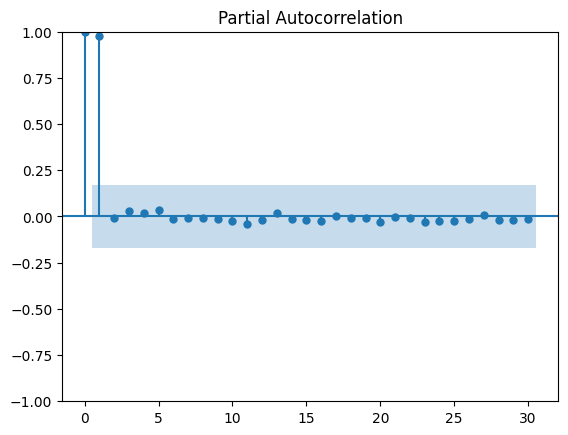

In [7]:
smt.graphics.tsa.plot_acf(cpi, lags=30, alpha = 0.05)
smt.graphics.tsa.plot_pacf(cpi, lags=30, alpha = 0.05)
plt.plot()

time-series plot has an up-ward trend,not mean stationary

ACF dies down slowly, not station

### ADF

In [8]:
from statsmodels.tsa.stattools import adfuller
# Check the stationarity using a statistical test
#  H0 : Time series is non-sationary vs H1: Time series is stationary


In [9]:
def test_stationarity(timeseries):
    # Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')

    # Print test outputs
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','pvalue','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

def plot_curve(timeseries):
    # Determing rolling statistics
    rolmean = timeseries.rolling(12,center=True).mean()
    rolstd = timeseries.rolling(12,center=True).std()

    # Plot rolling statistics:
    plt.figure(figsize=(13,6))
    plt.plot(timeseries, color='blue',label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.grid()
    plt.show()

Results of Dickey-Fuller Test:
Test Statistic                   0.948466
pvalue                           0.993691
#Lags Used                       2.000000
Number of Observations Used    129.000000
Critical Value (1%)             -3.482088
Critical Value (5%)             -2.884219
Critical Value (10%)            -2.578864
dtype: float64


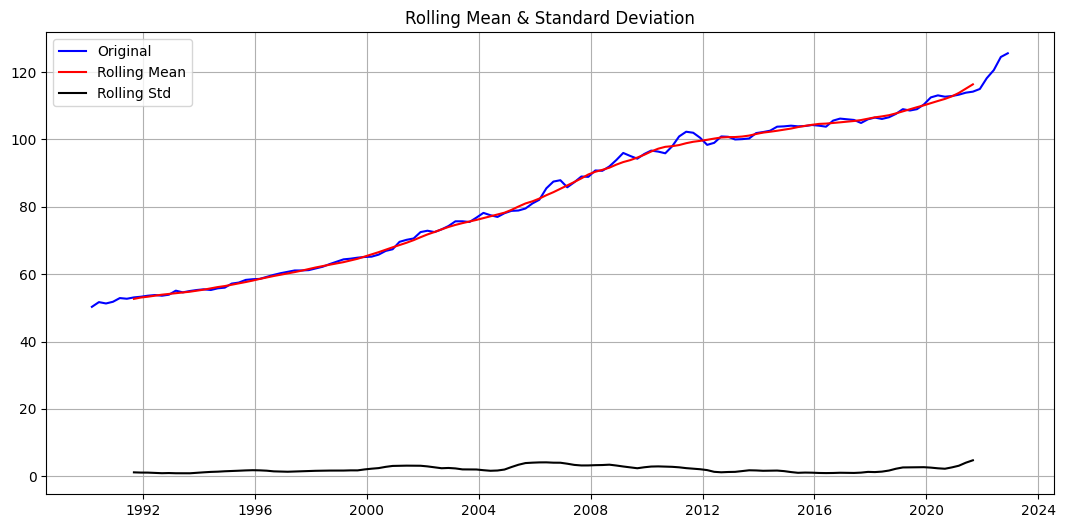

In [10]:
# Call test_stationarity() function to perform Dickey-Fuller test for the original series
test_stationarity(cpi)

# Then call the plot_curve() to visualize the original, rolling mean and rolling std series
plot_curve(cpi)

# H0 : Time series is non-sationary vs H1: Time series is stationary
# P value > 0.05, we do not reject H0: (Non - stationary)
# test stat with critical value (0.05)

Please pay attention to the above plot and test results. Clearly, this is not stationary because:
- Rolling mean is increasing even though the std is small.
- The p-value is 0.99, which is higher than significant levels at 1%, 5% and 10% then we do not reject the $H_0$, which states that the given time series is non-stationary.


## train-validation split

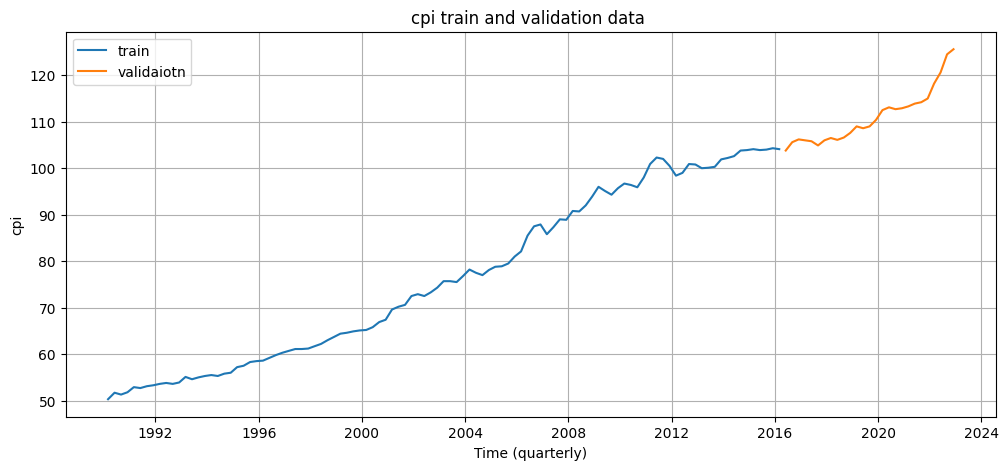

105
27


In [11]:

# Compute in-sample and out-of-sample size
T_train= int((len(cpi)) * 0.8)
T_vali= len(cpi) - T_train
train = cpi[:T_train]
vali = cpi[-T_vali:]
# Plot train and validaiton data

plt.figure(figsize=(12,5))
plt.plot(train)
plt.plot(vali)
plt.title('cpi train and validation data ')
plt.xlabel('Time (quarterly)')
plt.ylabel('cpi')
plt.legend(['train','validaiotn'])
plt.grid()
plt.show()
print(T_train)
print(T_vali)

In [12]:
from sklearn.metrics import mean_squared_error

# Models

## 1. Naive forest (1-step, 2-step....27-step ahead forecast for final training data)


In [13]:
vali_forecast_df = pd.DataFrame(vali)
vali_forecast = pd.Series(np.zeros(T_vali))
vali_forecast.index = vali.index
for i in np.arange(T_vali):
  vali_forecast.iloc[i] = train.iloc[-1]
vali_forecast_df[f'forecast'] =vali_forecast
vali_forecast_df

,CPI,forecast
Quarter,,
2016-06-01,103.8,104.1
2016-09-01,105.6,104.1
2016-12-01,106.2,104.1
2017-03-01,106.0,104.1
2017-06-01,105.8,104.1
2017-09-01,104.9,104.1
2017-12-01,106.0,104.1
2018-03-01,106.5,104.1
2018-06-01,106.1,104.1


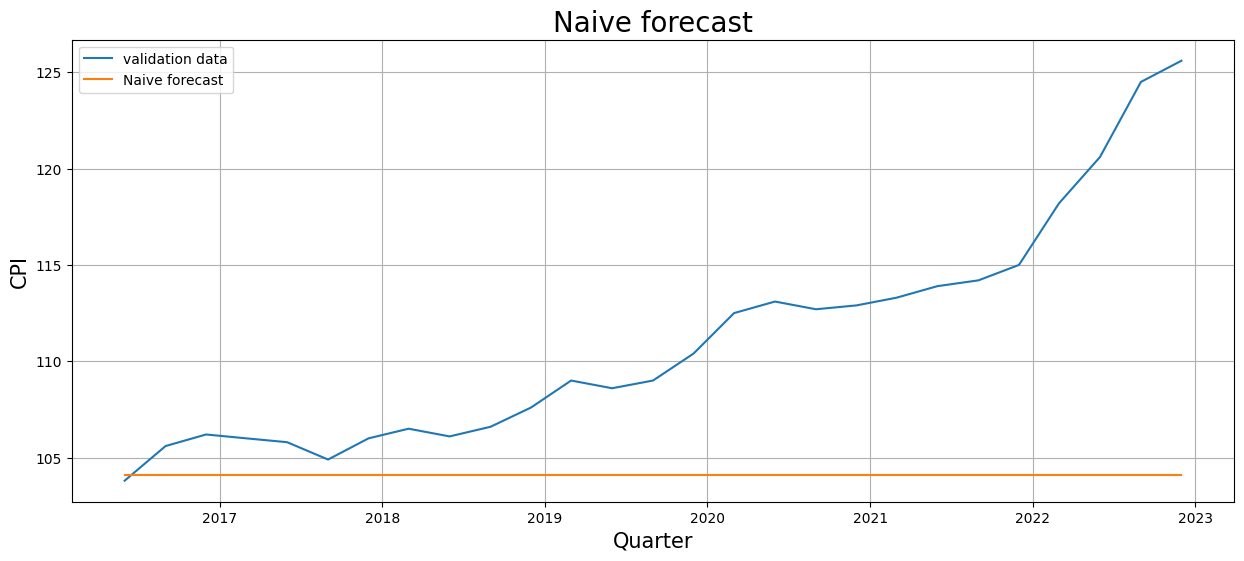

In [14]:
plt.figure(figsize=(15,6))
plt.plot(vali, label="validation data")
plt.plot(vali_forecast, label="Naive forecast")
plt.xlabel('Quarter', fontsize=15)
plt.ylabel('CPI', fontsize=15)
plt.title("Naive forecast", fontsize=20)
plt.legend()
plt.grid()
plt.show()


### Naive MSE

In [15]:
naive_vali_mse = mean_squared_error(vali,vali_forecast)
print("naive_vali_MSE:{:.4f}".format(naive_vali_mse))

naive_vali_MSE:81.7648


## 2. TCES

In [16]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
fit_add = ExponentialSmoothing(train, trend='add', seasonal=None).fit()
# symbol r $ and \ in the results variable are the latex symbols for visualization in notebook
results = pd.DataFrame(index=[r"$\alpha$",\
                              r"$\beta$",\
                              r"$\gamma$",\
                              r"$l_0$",\
                              "$b_0$",\
                              "SSE"])
# ExponentialSmoothing() object has following attributes
params = ['smoothing_level', \
          'smoothing_trend', \
          'smoothing_seasonal', \
          'initial_level', \
          'initial_trend']

# check out the performance of additive and multiplicative
results["Additive"]= [fit_add.params[p] for p in params] + [fit_add.sse]
print(results)

              Additive
$\alpha$  1.000000e+00
$\beta$   1.082644e-13
$\gamma$           NaN
$l_0$     4.978269e+01
$b_0$     5.173078e-01
SSE       8.308885e+01


In [17]:
future_steps = T_vali
forecast = fit_add.forecast(steps=future_steps)
print(f"future {future_steps} step：\n", forecast)

future 27 step：
 2016-06-01    104.617308
2016-09-01    105.134616
2016-12-01    105.651923
2017-03-01    106.169231
2017-06-01    106.686539
2017-09-01    107.203847
2017-12-01    107.721154
2018-03-01    108.238462
2018-06-01    108.755770
2018-09-01    109.273078
2018-12-01    109.790386
2019-03-01    110.307693
2019-06-01    110.825001
2019-09-01    111.342309
2019-12-01    111.859617
2020-03-01    112.376925
2020-06-01    112.894232
2020-09-01    113.411540
2020-12-01    113.928848
2021-03-01    114.446156
2021-06-01    114.963463
2021-09-01    115.480771
2021-12-01    115.998079
2022-03-01    116.515387
2022-06-01    117.032695
2022-09-01    117.550002
2022-12-01    118.067310
Freq: QS-DEC, dtype: float64


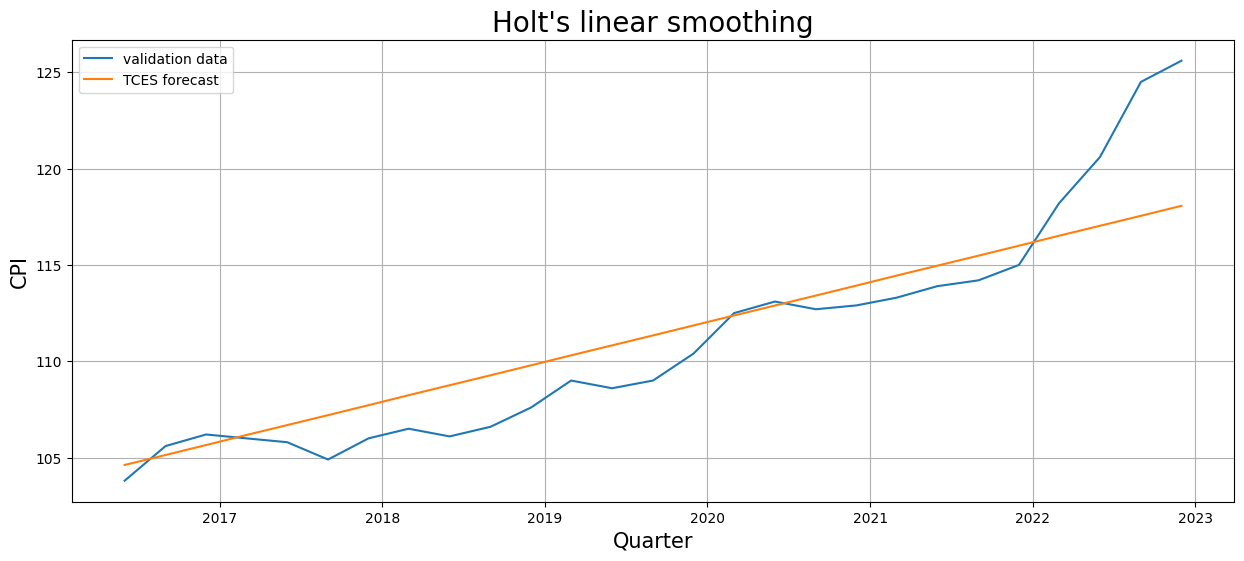

In [18]:
# Ploting the smoothing and forecast results
plt.figure(figsize=(15,6))
plt.plot(vali, label="validation data")
plt.plot(forecast, label="TCES forecast")
plt.xlabel('Quarter', fontsize=15)
plt.ylabel('CPI', fontsize=15)
plt.title("Holt's linear smoothing", fontsize=20)
plt.legend()
plt.grid()
plt.show()

### TCES mse

In [19]:
TCES_vali_mse = mean_squared_error(vali,forecast)
print("TCES_vali_MSE:{:.4f}".format(TCES_vali_mse))

TCES_vali_MSE:6.4399


## 3. ARIMA

### ARIMA(2,1,2)

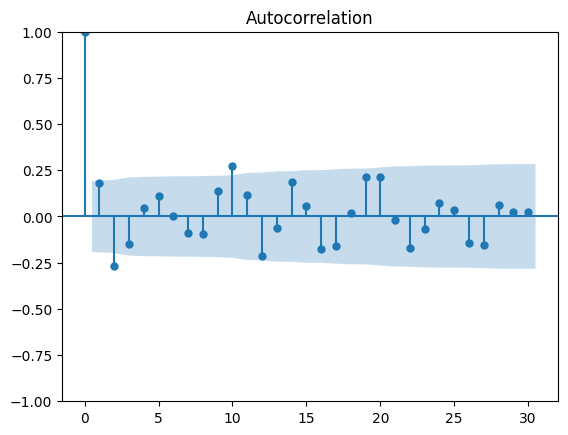

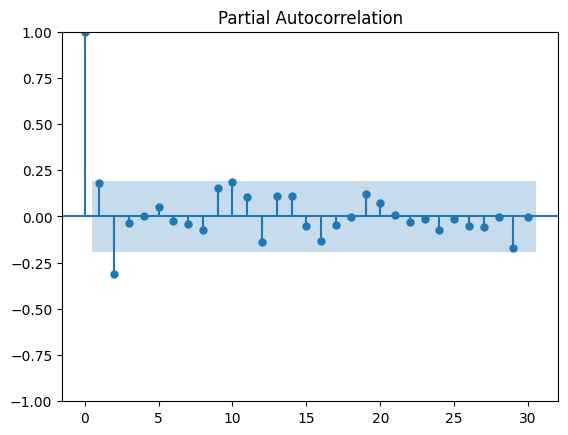

In [20]:
train_diff = pd.Series.diff(train)
train_diff = train_diff.dropna()
# Sample ACF
smt.graphics.tsa.plot_acf(train_diff, lags=30, alpha = 0.05)
plt.show()

# Sample PACF
smt.graphics.tsa.plot_pacf(train_diff, lags=30, alpha = 0.05)
plt.show()

The sample ACF die down quickly and cut-off after lag 2. In this case, it's reasonable to say that the differenced data is stationary and hence we don't need to apply another differencing step. Then we could set the  d=1  for the  ARIMA(p,d,q)  process.

ACF cut-off after lag 2, and PACF cut-off after lag 2 ,so we use ARIMA(2,1,2)

In [21]:
from statsmodels.tsa.arima.model import ARIMA
# Create an ARIMA (2,1,2) model
model = ARIMA(train, order=(2, 1, 2))
model_fit = model.fit()

# Get the summary of the fitted model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    CPI   No. Observations:                  105
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -133.364
Date:                Fri, 01 Nov 2024   AIC                            276.727
Time:                        05:45:11   BIC                            289.949
Sample:                    03-01-1990   HQIC                           282.084
                         - 03-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6705      0.241      2.784      0.005       0.198       1.142
ar.L2          0.3295      0.241      1.365      0.172      -0.144       0.802
ma.L1         -0.3704      0.254     -1.455      0.1

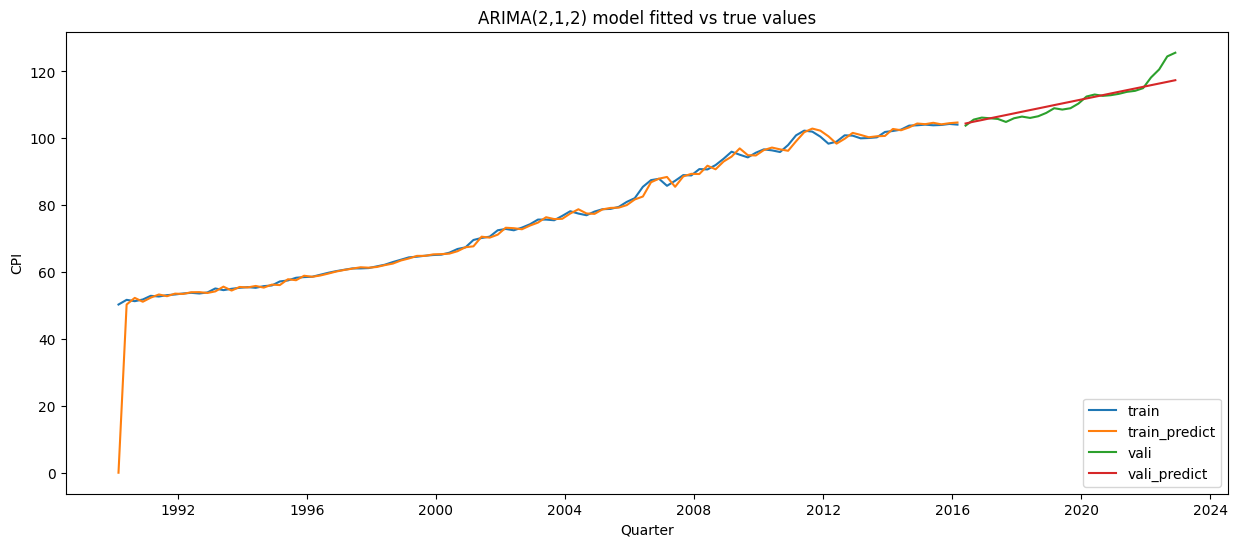

In [22]:
train_predict=model_fit.predict()
vali_predict=model_fit.forecast(steps=len(vali))
plt.figure(figsize=(15,6))
plt.plot(train,label='train')
plt.plot(train_predict,label='train_predict')
plt.plot(vali,label='vali')
plt.plot(vali_predict,label='vali_predict')
plt.xlabel('Quarter')
plt.ylabel('CPI')
plt.title("ARIMA(2,1,2) model fitted vs true values")
plt.legend(loc=4)
plt.show()

### ARIMA(2,1,2) MSE


In [23]:

ARIMA212_train_mse = mean_squared_error(train[1:],train_predict[1:])
print("ARIMA(2,1,2)_train_MSE:{:.4f}".format(ARIMA212_train_mse))

ARIMA212_vali_mse = mean_squared_error(vali,vali_predict)
print("ARIMA(2,1,2)_vali_MSE:{:.4f}".format(ARIMA212_vali_mse))

ARIMA(2,1,2)_train_MSE:0.7570
ARIMA(2,1,2)_vali_MSE:6.8361


### auto_arima model

In [24]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 12.0 MB/s eta 0:00:00


In [25]:
import pmdarima as pm
model = pm.auto_arima(
    train,
    start_p=0,              # Starting point for p
    start_q=0,              # Starting point for q
    max_p=5,                # Maximum p value to test
    max_q=5,                # Maximum q value to test
    d=None,                 # Automatically determine d (differencing)
    seasonal=False,         # Set to True for seasonal data (SARIMA)
    stepwise=True,          # Use stepwise search to improve speed
    trace=True,             # Output search progress
    error_action='ignore',  # Ignore convergence warnings
    suppress_warnings=True, # Suppress other warnings
    information_criterion='aic',  # Select the model with the lowest AIC
)

# Summary of the best model
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=275.793, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=274.315, Time=0.27 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=270.624, Time=0.66 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=303.839, Time=0.12 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=270.474, Time=2.13 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=267.382, Time=3.52 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=265.443, Time=1.89 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=267.379, Time=1.15 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=269.379, Time=1.55 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=289.642, Time=0.18 sec

Best model:  ARIMA(2,1,0)(0,0,0)[0] intercept
Total fit time: 11.653 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  105
Model:               SARIMAX(2, 1, 0)   Log Likelihood                -

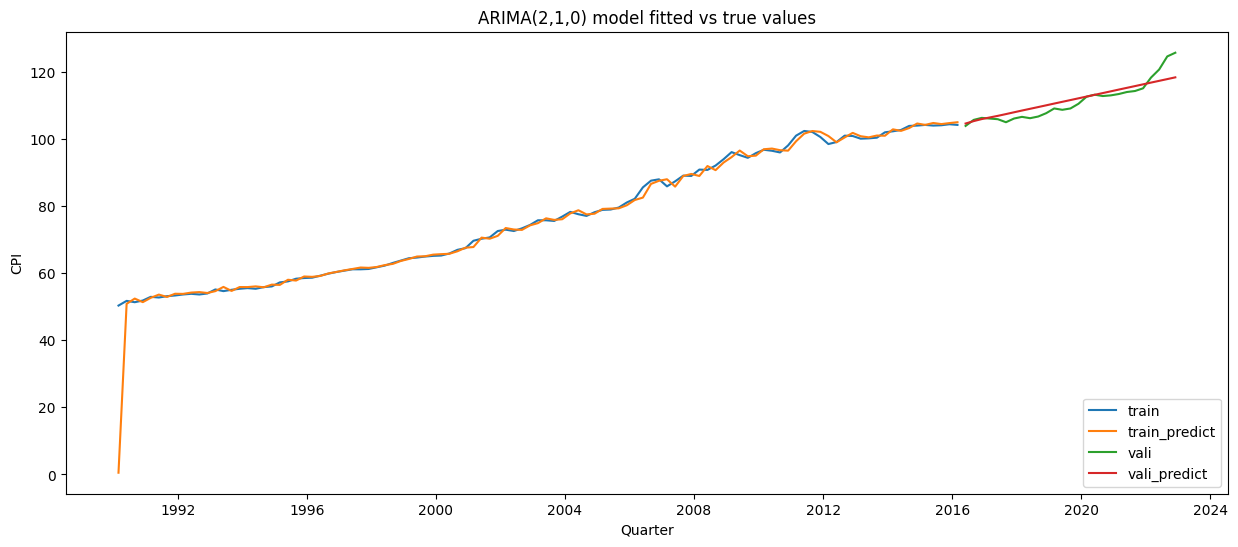

In [26]:
train_predict=model.predict_in_sample()
vali_predict=model.predict(n_periods=len(vali))
plt.figure(figsize=(15,6))
plt.plot(train,label='train')
plt.plot(train_predict,label='train_predict')
plt.plot(vali,label='vali')
plt.plot(vali_predict,label='vali_predict')
plt.xlabel('Quarter')
plt.ylabel('CPI')
plt.title("ARIMA(2,1,0) model fitted vs true values")
plt.legend(loc=4)
plt.show()

### arima(2,1,0) with intercept MSE

In [27]:
ARIMA210_train_mse = mean_squared_error(train[1:],train_predict[1:])
print("ARIMA210_train_MSE:{:.4f}".format(ARIMA210_train_mse))

ARIMA210_vali_mse = mean_squared_error(vali,vali_predict)
print("ARIMA210_vali_MSE:{:.4f}".format(ARIMA210_vali_mse))

ARIMA210_train_MSE:0.6964
ARIMA210_vali_MSE:6.4733


## RNN （LSTM）


In [ ]:
!pip install tensorflow

In [ ]:
!pip install scikeras

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Library for neural networks
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM, Activation
from tensorflow.keras.models import Sequential

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 8)                   │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 8)                   │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0800 - val_loss: 0.6828
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0468 - val_loss: 0.4840
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0287 - val_loss: 0.3215
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0221 - val_loss: 0.1994
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0243 - val_loss: 0.1187
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0300 - val_loss: 0.0732
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0336 - val_loss: 0.0505
Epoch 8/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0331 - val_loss: 0.0389
Epoch 9/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0299 - val_loss: 0.0316
Epoch 10/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0258 - val_loss: 0.0257
Epoch 11/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0219 - val_loss: 0.0204
Epoch 12/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

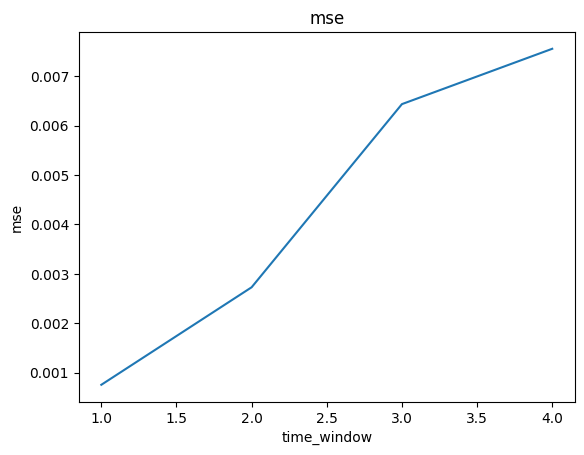

In [ ]:
mse_test=[] # Initialize an empty list called mse_test
time_window_values=np.arange(1,5,1) # Changed variable name to avoid confusion
for time_window in time_window_values: # Iterate over actual time window values
  scaler = MinMaxScaler(feature_range=(0, 1))
  train_size = int((len(cpi)-time_window) * 0.8)
  test_size = len(cpi) - train_size-time_window
  fitted_transformer =scaler.fit(cpi.iloc[:train_size+time_window])
  data_scaled = fitted_transformer.transform(cpi)
  # Pre-allocation
  Xall, Yall = [], []
  Xall_not_scaled, Yall_not_scaled = [], []
  # Use each rolling window as a row in the data matrix
  for i in range(time_window, len(data_scaled)):
      Xall.append(data_scaled[i-time_window:i, 0])
      Xall_not_scaled.append(cpi.iloc[i-time_window:i, 0].values) # Use .iloc and .values
      Yall.append(data_scaled[i, 0])
      Yall_not_scaled.append(cpi.iloc[i, 0])
  # Convert them from list to array
  Xall = np.array(Xall)
  Yall = np.array(Yall)
  Xall_not_scaled = np.array(Xall_not_scaled)
  Yall_not_scaled = np.array(Yall_not_scaled)
  # Training data
  Xtrain = Xall[:train_size, :]
  Ytrain = Yall[:train_size]
  # Test data
  Xtest = Xall[-test_size:, :]
  Ytest = Yall[-test_size:]
  # For time series and LSTM layer we need to reshape into 3D array
  Xtrain = np.reshape(Xtrain, (Xtrain.shape[0], time_window,1))
  Xtest = np.reshape(Xtest, (Xtest.shape[0], time_window,1))
  model = Sequential()
  model.add(LSTM(units=8,input_shape = (time_window,1)))
  model.add(Dense(units=1))
  model.compile(loss="mean_squared_error", optimizer="adam")
  model.summary()
  from tensorflow.keras.callbacks import EarlyStopping
  early_stop = EarlyStopping(monitor='val_loss', patience=50, verbose=1)
  model.fit(Xtrain, Ytrain,
          batch_size = 5,
          epochs = 200,
          validation_split = 0.1,
          shuffle = False,
          verbose = 1,
          callbacks = [early_stop])
  # Predicting
  allPredict = model.predict(np.reshape(Xall, (Xall.shape[0],time_window,1)))
  #Transforming to original scale
  allPredict_original_scale = scaler.inverse_transform(allPredict)
  allPredictPlot = np.empty_like(data_scaled)
  allPredictPlot[:, :] = np.nan
  allPredictPlot[time_window:, :] = allPredict_original_scale
  mse_test.append(mean_squared_error(Ytest, allPredict[-test_size:,0])) # Appending to the now initialized mse_test list
plt.plot(time_window_values, mse_test)
plt.xlabel('time_window')
plt.ylabel('mse')
plt.title('mse')
plt.show()

In [ ]:
arg_min = np.unravel_index(np.array(mse_test).argmin(), (len(mse_test),)) # Convert mse_test to a NumPy array
print('Optimal time window:{}'.format(time_window_values[arg_min[0]]))

Optimal time window:1


In [ ]:
time_window=1
scaler = MinMaxScaler(feature_range=(0, 1))
train_size = int((len(cpi)-time_window) * 0.8)
vali_size = len(cpi) - train_size-time_window
fitted_transformer =scaler.fit(cpi.iloc[:train_size+time_window])
data_scaled = fitted_transformer.transform(cpi)
  # Pre-allocation
Xall, Yall = [], []
Xall_not_scaled, Yall_not_scaled = [], []
# Use each rolling window as a row in the data matrix
for i in range(time_window, len(data_scaled)):
    Xall.append(data_scaled[i-time_window:i, 0])
    Xall_not_scaled.append(cpi.iloc[i-time_window:i, 0].values) # Use .iloc and .values
    Yall.append(data_scaled[i, 0])
    Yall_not_scaled.append(cpi.iloc[i, 0])
# Convert them from list to array
Xall = np.array(Xall)
Yall = np.array(Yall)
Xall_not_scaled = np.array(Xall_not_scaled)
Yall_not_scaled = np.array(Yall_not_scaled)
# Training data
Xtrain = Xall[:train_size, :]
Ytrain = Yall[:train_size]
# Vali data
Xvali = Xall[-vali_size:, :]
Yvali = Yall[-vali_size:]
# For time series and LSTM layer we need to reshape into 3D array
Xtrain = np.reshape(Xtrain, (Xtrain.shape[0], time_window,1))
Xvali = np.reshape(Xvali, (Xvali.shape[0], time_window,1))

In [ ]:
from scikeras.wrappers import KerasRegressor
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
def RNN(units=8, optimizer='adam'):
  model = Sequential()
  model.add(LSTM(units=units, input_shape=(time_window, 1)))
  model.add(Dense(units=1))
  model.compile(loss="mean_squared_error", optimizer=optimizer)
  return model

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
random_seed = 32

model = KerasRegressor(model=RNN, verbose=0)

random_grid = {
    'model__units': list(range(4, 25, 4)),
    'batch_size': list(range(5, 26, 5)),
    'epochs': list(range(100, 501, 100)),}
    #'model__optimizer': ['adam', 'rmsprop']}
early_stop = EarlyStopping(monitor='val_loss', patience=50, verbose=1)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=random_grid,
    n_iter=35,
    scoring='neg_mean_squared_error',
    random_state=random_seed)
random_search_result = random_search.fit(Xtrain, Ytrain, validation_split=0.1, shuffle=False, callbacks=[early_stop])

In [ ]:
print("Best Parameters: ", random_search_result.best_params_)

best_mse = -random_search_result.best_score_
print("Best MSE: ", best_mse)

Best Parameters:  {'model__units': 12, 'epochs': 500, 'batch_size': 5}
Best MSE:  0.00027413868707791593


In [ ]:
import random as python_random
seed=42
np.random.seed(seed)
python_random.seed(seed)
tf.random.set_seed(seed)
model = Sequential()
model.add(LSTM(units=12,input_shape = (time_window,1)))
model.add(Dense(units=1))
model.compile(loss="mean_squared_error", optimizer="adam")
model.summary()
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=50, verbose=1)
model.fit(Xtrain, Ytrain,
          batch_size = 5,
          epochs = 500,
          validation_split = 0.1,
          shuffle = False,
          verbose = 1,
          callbacks = [early_stop])
# Predicting
allPredict = model.predict(np.reshape(Xall, (Xall.shape[0],time_window,1)))
#Transforming to original scale
allPredict_original_scale = scaler.inverse_transform(allPredict)
allPredictPlot = np.empty_like(data_scaled)
allPredictPlot[:, :] = np.nan
allPredictPlot[time_window:, :] = allPredict_original_scale

Model: "sequential_195"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_195 (LSTM)                      │ (None, 12)                  │             672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_195 (Dense)                    │ (None, 1)                   │              13 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 685 (2.68 KB)

 Trainable params: 685 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0770 - val_loss: 0.7465
Epoch 2/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0604 - val_loss: 0.6513
Epoch 3/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0485 - val_loss: 0.5654
Epoch 4/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0397 - val_loss: 0.4878
Epoch 5/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0338 - val_loss: 0.4179
Epoch 6/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0302 - val_loss: 0.3557
Epoch 7/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0288 - val_loss: 0.3012
Epoch 8/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0291 - val_loss: 0.2545
Epoch 9/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0306 - val_loss: 0.2152
Epoch 10/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0328 - val_loss: 0.1828
Epoch 11/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0352 - val_loss: 0.1565
Epoch 12/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step 

### LSTM MSE

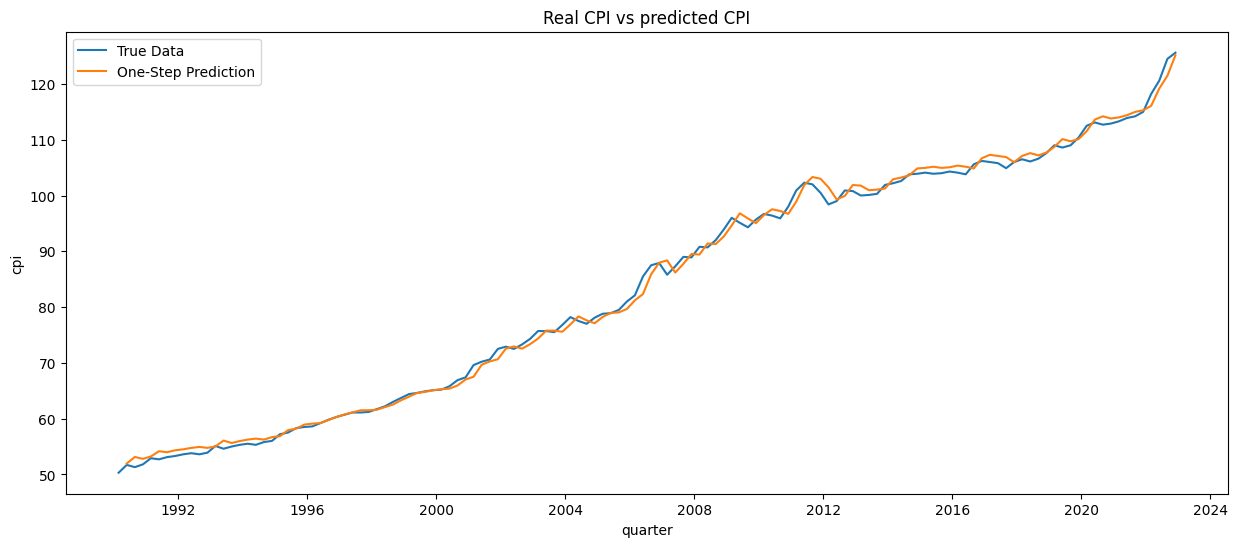

vali Data MSE: 1.3930
Training Data MSE: 0.5786


In [ ]:
# Plot true and in-sample forecast values
plt.figure(figsize=(15,6))
plt.plot(cpi.index,scaler.inverse_transform(data_scaled), label='True Data')
plt.plot(cpi.index,allPredictPlot, label='One-Step Prediction')
plt.xlabel('quarter')
plt.ylabel('cpi')
plt.title('Real CPI vs predicted CPI')
plt.legend()
plt.show()

# Checking training and test score
LSTM_vali_mse =mean_squared_error(cpi.iloc[-vali_size:, :], allPredict_original_scale[-vali_size:,0])

print('vali Data MSE: {0:.4f}'.format(LSTM_vali_mse))
LSTM_train_mse= mean_squared_error(cpi.iloc[:train_size, :], allPredict_original_scale[:train_size,0])
print('Training Data MSE: {0:.4f}'.format(LSTM_train_mse))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

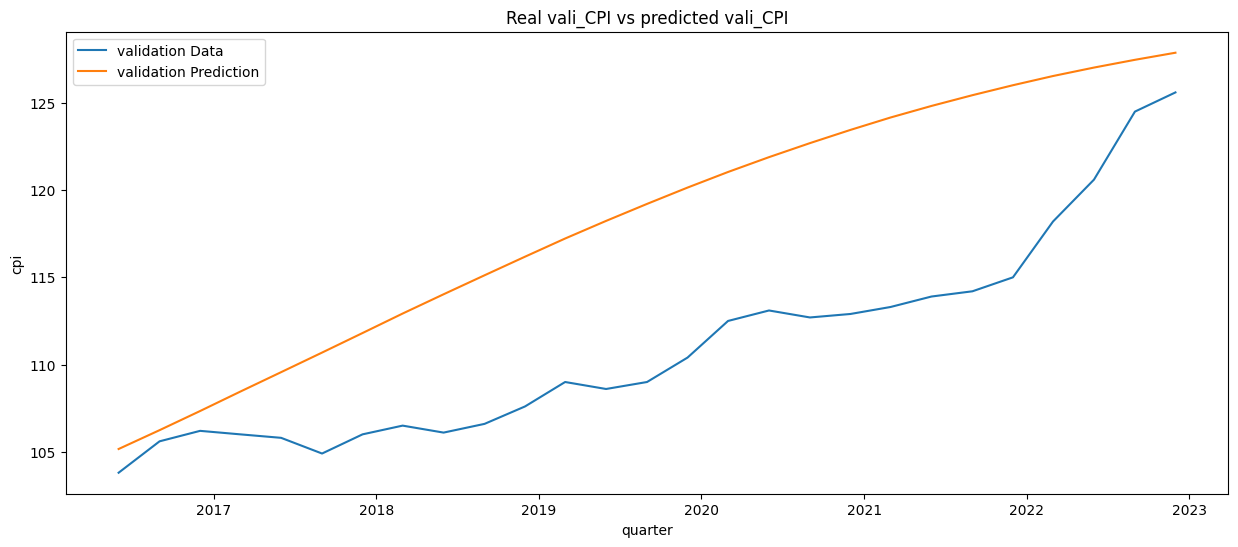

scaled_validation Data RMSE: 0.0212
Dynamic Forecast MSE: 61.9284


In [ ]:
#Dynamical Prediction
dynamic_prediction = np.copy(data_scaled[:len(data_scaled) - vali_size])

for i in range(len(data_scaled) - vali_size, len(data_scaled)):
    last_feature = np.reshape(dynamic_prediction[i-time_window:i], (1,time_window,1))
    next_pred = model.predict(last_feature)
    dynamic_prediction = np.append(dynamic_prediction, next_pred)

# Transform forecast values to original scale
dynamic_prediction = dynamic_prediction.reshape(-1,1)
dynamic_prediction_original_scale = scaler.inverse_transform(dynamic_prediction)


plt.figure(figsize=(15,6))
plt.plot(cpi.iloc[-vali_size:, :].index, scaler.inverse_transform(data_scaled[-vali_size:]), label='validation Data')
plt.plot(cpi.iloc[-vali_size:, :].index, dynamic_prediction_original_scale[-vali_size:], label='validation Prediction')
plt.legend(loc = "upper left")
plt.xlabel('quarter')
plt.ylabel('cpi')
plt.title('Real vali_CPI vs predicted vali_CPI')
plt.show()

# Compute RMSE score on test data
valiScore = mean_squared_error(Yvali, dynamic_prediction[-vali_size:])
print('scaled_validation Data RMSE: {0:.4f}'.format(valiScore))
LSTM_vali_dynamic_mse = mean_squared_error(cpi.iloc[-vali_size:, :], dynamic_prediction_original_scale[-vali_size:])
print('Dynamic Forecast MSE: {0:.4f}'.format(LSTM_vali_dynamic_mse))

## MSE compare (model selection)

In [ ]:
models = ['Naive', 'TCES', 'ARIMA(2,1,2)', 'ARIMA(2,1,0)with intercept',"LSTM dynamical prediction"]
mse_values = [naive_vali_mse, TCES_vali_mse, ARIMA212_vali_mse, ARIMA210_vali_mse,LSTM_vali_dynamic_mse]
data = {'Model': models, 'MSE': mse_values}
df = pd.DataFrame(data).round(4)
df

,Model,MSE
0,Naive,81.7648
1,TCES,6.4399
2,"ARIMA(2,1,2)",6.8361
3,"ARIMA(2,1,0)with intercept",6.4733
4,LSTM dynamical prediction,61.9284


# Final model

In [28]:
import pmdarima as pm
final_model = pm.auto_arima(
    cpi,
    start_p=2,              # Starting point for p
    start_q=0,              # Starting point for q
    d=None,                 # Automatically determine d (differencing)
    seasonal=False,         # Set to True for seasonal data (SARIMA)
    stepwise=True,          # Use stepwise search to improve speed
    trace=True,             # Output search progress
    error_action='ignore',  # Ignore convergence warnings
    suppress_warnings=True, # Suppress other warnings
    information_criterion='aic'  # Select the model with the lowest AIC
)

# Summary of the best model
print(final_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=349.269, Time=1.54 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=362.034, Time=0.26 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=355.003, Time=0.26 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=350.585, Time=0.86 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=400.978, Time=0.11 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=351.263, Time=1.30 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=351.264, Time=2.96 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=351.771, Time=1.53 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=353.251, Time=0.58 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=374.211, Time=0.23 sec

Best model:  ARIMA(2,1,0)(0,0,0)[0] intercept
Total fit time: 9.680 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  132
Model:               SARIMAX(2, 1, 0)   Log Likelihood                -1

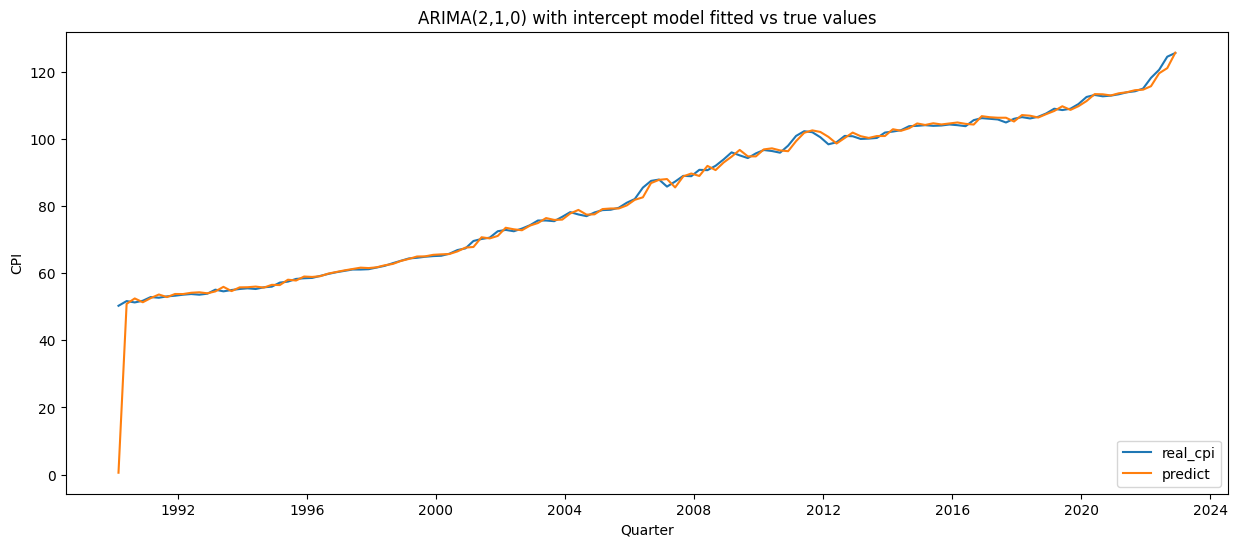

In [29]:
predict=final_model.predict_in_sample()
plt.figure(figsize=(15,6))
plt.plot(cpi,label='real_cpi')
plt.plot(predict,label='predict')
plt.xlabel('Quarter')
plt.ylabel('CPI')
plt.title("ARIMA(2,1,0) with intercept model fitted vs true values")
plt.legend(loc=4)
plt.show()

In [30]:
ARIMA212_mse = mean_squared_error(cpi[1:],predict[1:])
print("ARIMA(2,1,2)_MSE:{:.4f}".format(ARIMA212_mse))

ARIMA(2,1,2)_MSE:0.7925


# Forecast next 6 data

In [35]:
prediction = final_model.predict(n_periods=6)
print(round(prediction,4))

2023-03-01    125.5017
2023-06-01    125.7235
2023-09-01    126.3505
2023-12-01    127.0273
2024-03-01    127.6180
2024-06-01    128.1684
Freq: QS-DEC, dtype: float64


In [36]:
quarter= pd.date_range(start='2023Q1', periods=6, freq='Q')
data = {'Predicted Values': np.round(prediction, 4)}

predict_df = pd.DataFrame(data)

predict_df.to_csv('prediction.csv')


# Qualitative Analysis

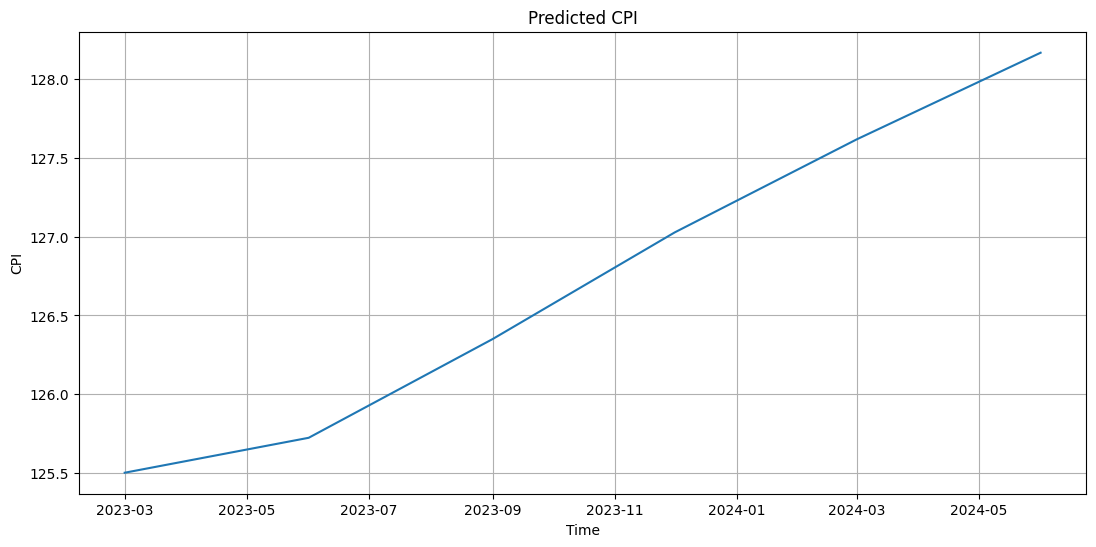

In [37]:
#plot the predictions for CPI
# = cashrate['Cashrate']

# Plot data
plt.figure(figsize=(13,6))
plt.plot(predict_df.index,predict_df['Predicted Values'])
plt.xlabel('Time')
plt.ylabel('CPI')
plt.title('Predicted CPI')
plt.grid()
plt.show()

In [ ]:
cashrate = pd.read_excel('/content/cashrate_data.xlsx')
cashrate['Date']=pd.to_datetime(cashrate['Date'])
cashrate.set_index('Date', inplace=True)

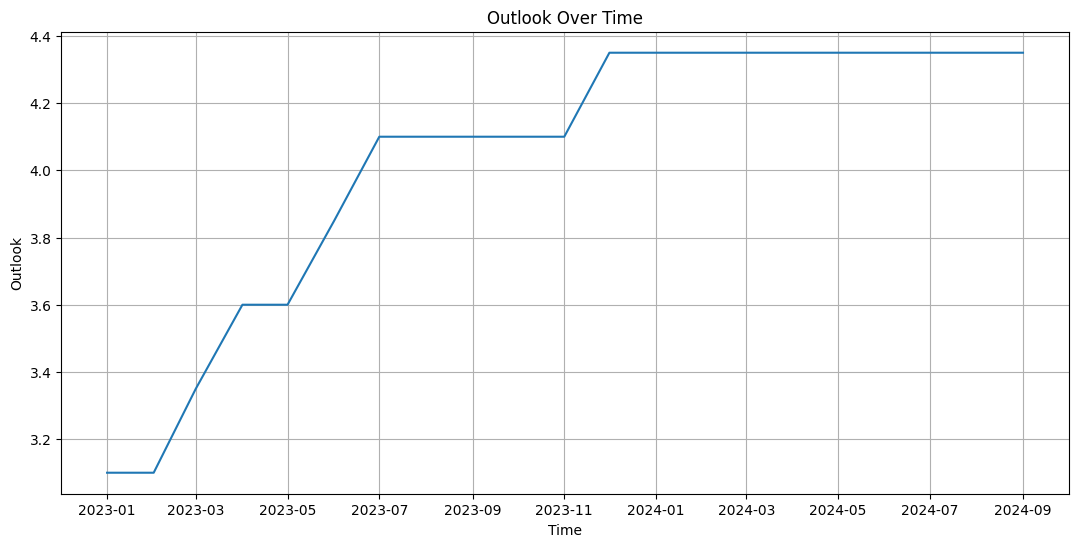

In [ ]:
#plot the outlook data for cashrate

# Load the second sheet of the Excel file
outlook_data = pd.read_excel('/content/cashrate_data.xlsx', sheet_name=1, header=None)

# Assuming the first column is the date and the second column is the 'outlook'
outlook_data.columns = ['Date', 'Outlook']
outlook_data['Date'] = pd.to_datetime(outlook_data['Date'])
outlook_data.set_index('Date', inplace=True)

# Plot the 'outlook' data
plt.figure(figsize=(13, 6))
plt.plot(outlook_data.index, outlook_data['Outlook'])
plt.xlabel('Time')
plt.ylabel('Outlook')
plt.title('Outlook Over Time')
plt.grid()
plt.show()

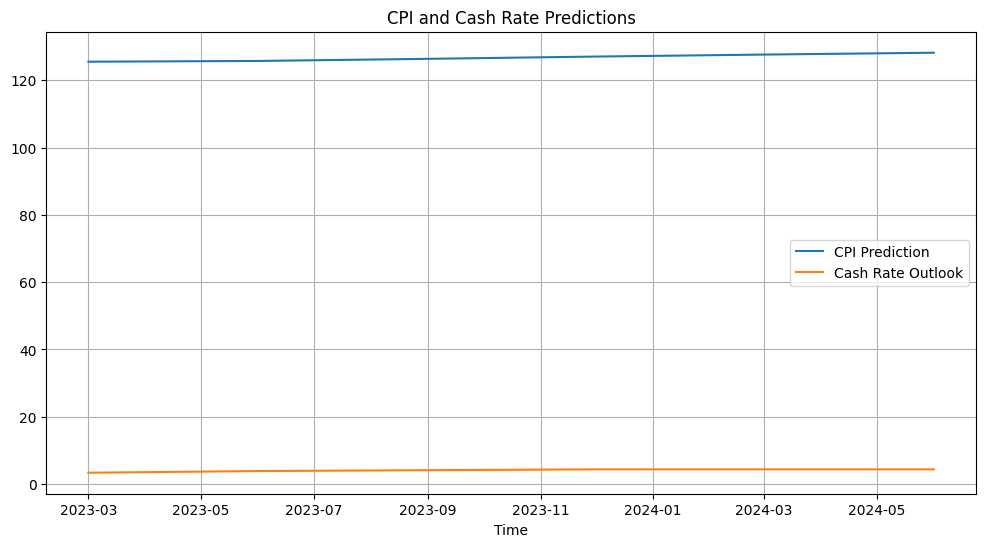

                  Predicted Values   Outlook
Predicted Values          1.000000  0.862177
Outlook                   0.862177  1.000000


In [ ]:
# Merge data
CPI_cashrate = pd.merge(predict_df, outlook_data, left_index=True, right_index=True, how='inner')

# Plot
plt.figure(figsize=(12,6))
plt.plot(CPI_cashrate.index, CPI_cashrate['Predicted Values'], label='CPI Prediction')
plt.plot(CPI_cashrate.index, CPI_cashrate['Outlook'], label='Cash Rate Outlook')
plt.legend()
plt.xlabel('Time')
plt.title('CPI and Cash Rate Predictions')
plt.grid()
plt.show()

# Correlation matrix
correlation = CPI_cashrate.corr()
print(correlation)

In [ ]:
import pandas as pd
prediction=pd.read_csv('prediction.csv')
cpi_test = pd.read_csv('CPI_test.csv')
test_error = mean_squared_error(cpi_test['CPI'], prediction['Predicted Values'])
print(test_error)

FileNotFoundError: [Errno 2] No such file or directory: 'CPI_test.csv'